<a href="https://colab.research.google.com/github/aniray2908/Blockchain-Project/blob/main/01_nlp_fundamentals/demos/06_text_classification_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Cell 2 — Create a Synthetic Dataset**

In [2]:
# Movie review sentiments (real examples paraphrased)
reviews = [
    "This movie is absolutely amazing and I loved every second of it",
    "Terrible film, waste of time and money, don't bother",
    "Great acting and wonderful cinematography, highly recommend",
    "Boring and predictable, fell asleep halfway through",
    "Best movie I've seen all year, masterpiece",
    "Awful dialogue and bad plot, completely disappointed",
    "Fantastic story with excellent performances by all actors",
    "Dreadful experience, one of the worst films ever made",
    "Outstanding visual effects and engaging narrative",
    "Poorly written and badly directed, disappointing",
    "Beautiful cinematography and moving story, truly great",
    "Unwatchable garbage, couldn't finish it",
    "Brilliant film that exceeded all expectations",
    "Horrible acting and weak plot, not recommended",
    "Excellent movie with memorable scenes and great music",
    "Absolutely dreadful, save your money",
    "Stunning visuals and compelling characters, loved it",
    "Painfully bad, one of the worst experiences",
    "Phenomenal performance, highly entertaining throughout",
    "Complete waste, poorly executed from start to finish",
]

labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

print(f"Dataset size: {len(reviews)} reviews")
print(f"Positive reviews: {sum(labels)}")
print(f"Negative reviews: {len(labels) - sum(labels)}")
print(f"\nFirst few reviews:")
for i in range(3):
    label = "Positive" if labels[i] == 1 else "Negative"
    print(f"  [{label}] {reviews[i]}")

Dataset size: 20 reviews
Positive reviews: 10
Negative reviews: 10

First few reviews:
  [Positive] This movie is absolutely amazing and I loved every second of it
  [Negative] Terrible film, waste of time and money, don't bother
  [Positive] Great acting and wonderful cinematography, highly recommend


**Cell 3 — Train/Test Split**

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    reviews, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels  # keep class balance in both splits
)

print(f"Training set: {len(X_train)} reviews")
print(f"Test set: {len(X_test)} reviews")
print(f"\nTrain label distribution:")
print(f"  Positive: {sum(y_train)}")
print(f"  Negative: {len(y_train) - sum(y_train)}")
print(f"\nTest label distribution:")
print(f"  Positive: {sum(y_test)}")
print(f"  Negative: {len(y_test) - sum(y_test)}")

Training set: 16 reviews
Test set: 4 reviews

Train label distribution:
  Positive: 8
  Negative: 8

Test label distribution:
  Positive: 2
  Negative: 2


**Cell 4 — Feature Extraction: BoW**

In [4]:
print("=" * 60)
print("FEATURE EXTRACTION: BAG OF WORDS")
print("=" * 60)

# Create vectoriser
bow_vectorizer = CountVectorizer(lowercase=True, stop_words='english')

# Fit on training data only!
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"\nVocabulary size: {len(bow_vectorizer.get_feature_names_out())}")
print(f"Training matrix shape: {X_train_bow.shape}")
print(f"Test matrix shape: {X_test_bow.shape}")
print(f"Sparsity: {(1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])) * 100:.1f}%")

# Show top features
top_features = bow_vectorizer.get_feature_names_out()[:20]
print(f"\nTop features (first 20): {list(top_features)}")

FEATURE EXTRACTION: BAG OF WORDS

Vocabulary size: 69
Training matrix shape: (16, 69)
Test matrix shape: (4, 69)
Sparsity: 92.5%

Top features (first 20): ['absolutely', 'acting', 'actors', 'amazing', 'asleep', 'awful', 'bad', 'badly', 'beautiful', 'boring', 'bother', 'characters', 'cinematography', 'compelling', 'complete', 'completely', 'couldn', 'dialogue', 'directed', 'disappointed']


**Cell 5 — Feature Extraction: TF-IDF**

In [5]:
print("\n" + "=" * 60)
print("FEATURE EXTRACTION: TF-IDF")
print("=" * 60)

# Create vectoriser
tfidf_vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', max_features=100)

# Fit on training data only!
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nVocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.1f}%")

# Show feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nFeature names: {list(feature_names[:15])}")

# Show TF-IDF values for first review
print(f"\nTF-IDF values for first review:")
dense = X_train_tfidf[0].toarray().flatten()
indices = np.argsort(dense)[-5:][::-1]  # top 5
for idx in indices:
    print(f"  {feature_names[idx]}: {dense[idx]:.3f}")


FEATURE EXTRACTION: TF-IDF

Vocabulary size: 69
Training matrix shape: (16, 69)
Test matrix shape: (4, 69)
Sparsity: 92.5%

Feature names: ['absolutely', 'acting', 'actors', 'amazing', 'asleep', 'awful', 'bad', 'badly', 'beautiful', 'boring', 'bother', 'characters', 'cinematography', 'compelling', 'complete']

TF-IDF values for first review:
  start: 0.435
  executed: 0.435
  complete: 0.435
  poorly: 0.379
  waste: 0.379


**Cell 6 — Model 1: Logistic Regression with BoW**

In [6]:
print("\n" + "=" * 60)
print("MODEL 1: LOGISTIC REGRESSION + BAG OF WORDS")
print("=" * 60)

# Train
clf_bow = LogisticRegression(max_iter=1000)
clf_bow.fit(X_train_bow, y_train)

# Predict
y_pred_bow = clf_bow.predict(X_test_bow)
y_pred_proba_bow = clf_bow.predict_proba(X_test_bow)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred_bow)
precision = precision_score(y_test, y_pred_bow)
recall = recall_score(y_test, y_pred_bow)
f1 = f1_score(y_test, y_pred_bow)
auc = roc_auc_score(y_test, y_pred_proba_bow)

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  AUC:       {auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_bow, target_names=['Negative', 'Positive']))


MODEL 1: LOGISTIC REGRESSION + BAG OF WORDS

Metrics:
  Accuracy:  0.750
  Precision: 1.000
  Recall:    0.500
  F1:        0.667
  AUC:       0.750

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
    Positive       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



**Cell 7 — Model 2: Logistic Regression with TF-IDF**

In [7]:
print("\n" + "=" * 60)
print("MODEL 2: LOGISTIC REGRESSION + TF-IDF")
print("=" * 60)

# Train
clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)

# Predict
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
y_pred_proba_tfidf = clf_tfidf.predict_proba(X_test_tfidf)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred_tfidf)
precision = precision_score(y_test, y_pred_tfidf)
recall = recall_score(y_test, y_pred_tfidf)
f1 = f1_score(y_test, y_pred_tfidf)
auc = roc_auc_score(y_test, y_pred_proba_tfidf)

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  AUC:       {auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))


MODEL 2: LOGISTIC REGRESSION + TF-IDF

Metrics:
  Accuracy:  0.750
  Precision: 1.000
  Recall:    0.500
  F1:        0.667
  AUC:       0.750

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
    Positive       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



**Cell 8 — Model 3: Naive Bayes**

In [8]:
print("\n" + "=" * 60)
print("MODEL 3: NAIVE BAYES + TF-IDF")
print("=" * 60)

# Train
clf_nb = MultinomialNB()
clf_nb.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = clf_nb.predict(X_test_tfidf)
y_pred_proba_nb = clf_nb.predict_proba(X_test_tfidf)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
auc = roc_auc_score(y_test, y_pred_proba_nb)

print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  AUC:       {auc:.3f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))


MODEL 3: NAIVE BAYES + TF-IDF

Metrics:
  Accuracy:  0.500
  Precision: 0.500
  Recall:    0.500
  F1:        0.500
  AUC:       0.750

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
    Positive       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



**Cell 9 — Model Comparison**


MODEL COMPARISON
                     accuracy  precision  recall     f1   auc
BoW + LogReg             0.75        1.0     0.5  0.667  0.75
TF-IDF + LogReg          0.75        1.0     0.5  0.667  0.75
TF-IDF + NaiveBayes      0.50        0.5     0.5  0.500  0.75


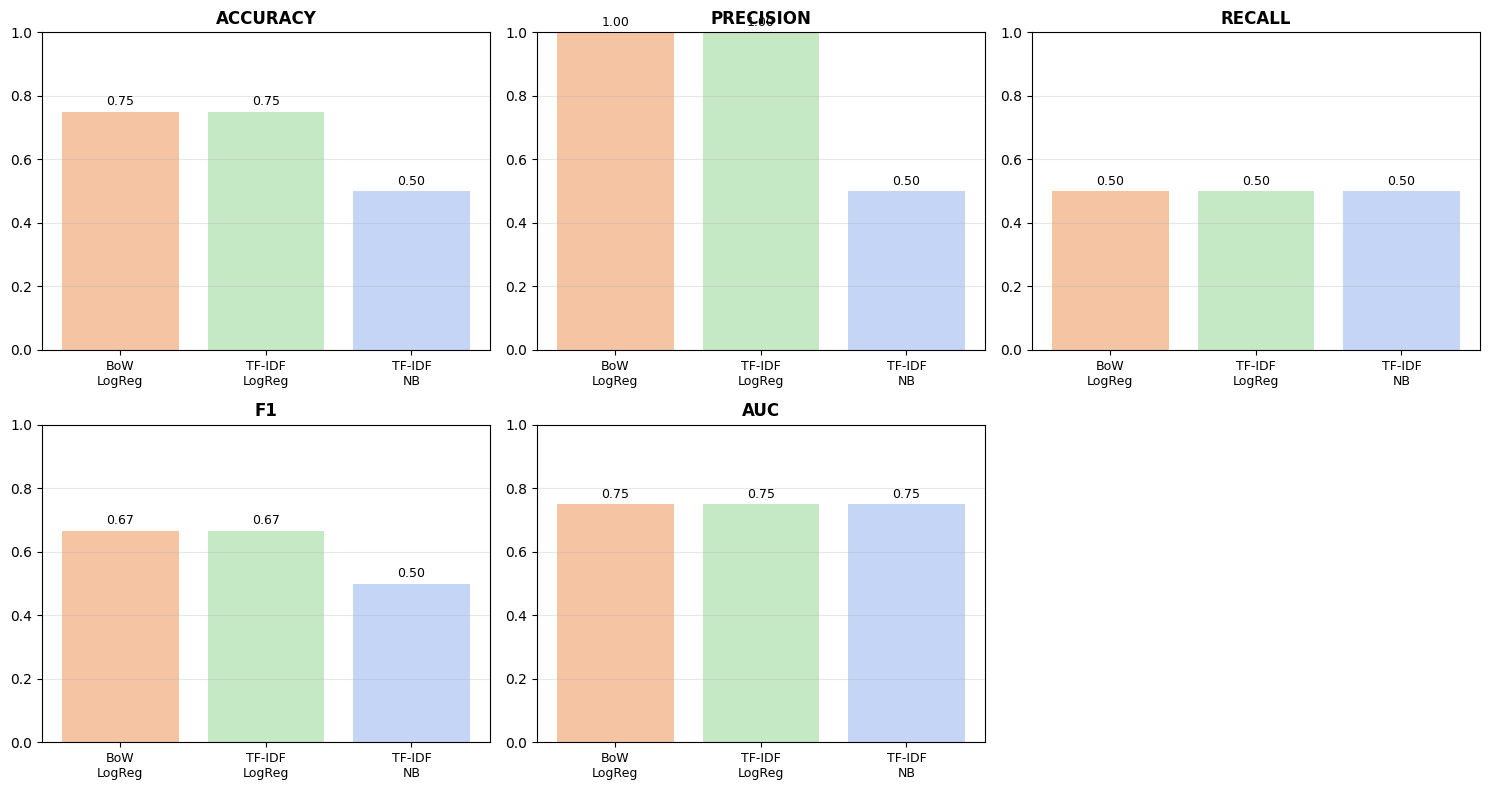


Best model: BoW + LogReg (accuracy: 0.750)


In [9]:
# Compare all models
results = {
    'BoW + LogReg': {
        'accuracy': accuracy_score(y_test, y_pred_bow),
        'precision': precision_score(y_test, y_pred_bow),
        'recall': recall_score(y_test, y_pred_bow),
        'f1': f1_score(y_test, y_pred_bow),
        'auc': roc_auc_score(y_test, y_pred_proba_bow),
    },
    'TF-IDF + LogReg': {
        'accuracy': accuracy_score(y_test, y_pred_tfidf),
        'precision': precision_score(y_test, y_pred_tfidf),
        'recall': recall_score(y_test, y_pred_tfidf),
        'f1': f1_score(y_test, y_pred_tfidf),
        'auc': roc_auc_score(y_test, y_pred_proba_tfidf),
    },
    'TF-IDF + NaiveBayes': {
        'accuracy': accuracy_score(y_test, y_pred_nb),
        'precision': precision_score(y_test, y_pred_nb),
        'recall': recall_score(y_test, y_pred_nb),
        'f1': f1_score(y_test, y_pred_nb),
        'auc': roc_auc_score(y_test, y_pred_proba_nb),
    }
}

df_results = pd.DataFrame(results).T
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(df_results.round(3))

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = [results[model][metric] for model in results.keys()]
    bars = ax.bar(range(len(results)), values, color=['#f5c5a3', '#c5e8c5', '#c5d5f5'])
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(['BoW\nLogReg', 'TF-IDF\nLogReg', 'TF-IDF\nNB'], fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

print(f"\nBest model: {df_results['accuracy'].idxmax()} (accuracy: {df_results['accuracy'].max():.3f})")

**Cell 10 — Confusion Matrix & Error Analysis**

In [ ]:
# Use best model (TF-IDF + LogReg)
best_model = clf_tfidf
best_pred = y_pred_tfidf

cm = confusion_matrix(y_test, best_model.predict(X_test_tfidf))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar=False)
plt.title("Confusion Matrix - Best Model (TF-IDF + LogReg)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives (TN):  {tn}  (correctly predicted negative)")
print(f"  False Positives (FP): {fp}  (negative predicted as positive)")
print(f"  False Negatives (FN): {fn}  (positive predicted as negative)")
print(f"  True Positives (TP):  {tp}  (correctly predicted positive)")

**Cell 11 — ROC Curve**

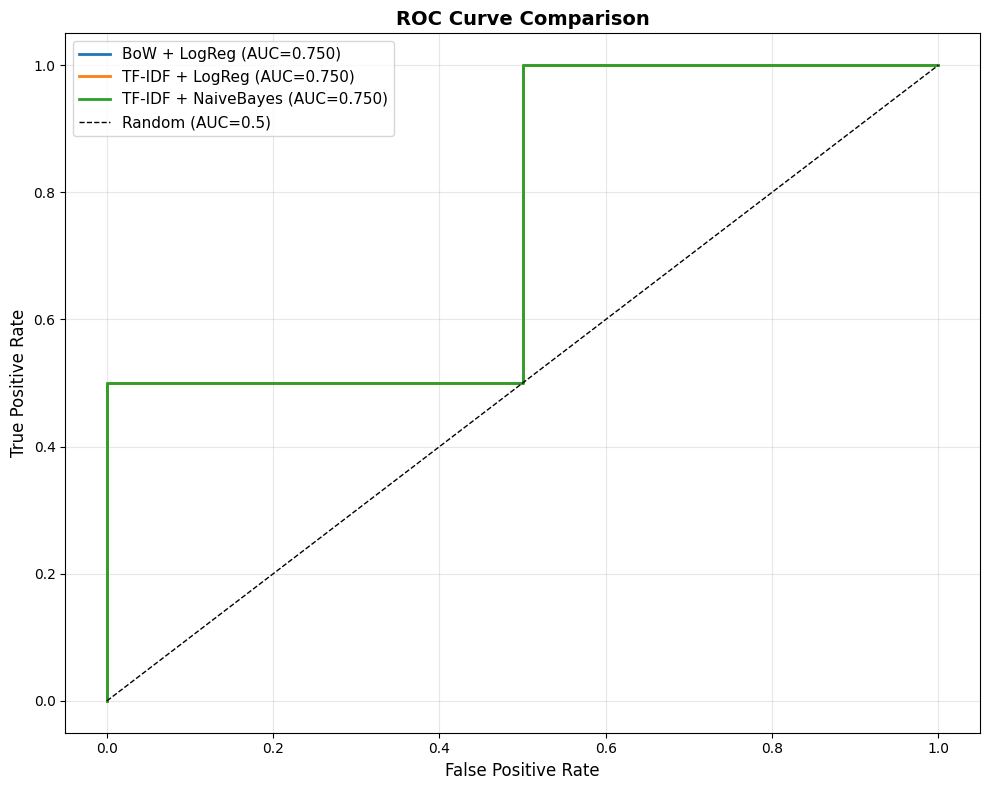

In [10]:
# Compute ROC curves for all models
fpr_bow, tpr_bow, _ = roc_curve(y_test, y_pred_proba_bow)
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_pred_proba_tfidf)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_bow, tpr_bow, label=f'BoW + LogReg (AUC={roc_auc_score(y_test, y_pred_proba_bow):.3f})', linewidth=2)
plt.plot(fpr_tfidf, tpr_tfidf, label=f'TF-IDF + LogReg (AUC={roc_auc_score(y_test, y_pred_proba_tfidf):.3f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'TF-IDF + NaiveBayes (AUC={roc_auc_score(y_test, y_pred_proba_nb):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Cell 12 — Predict on New Reviews**

In [11]:
# Test on new, unseen reviews
new_reviews = [
    "Absolutely incredible movie, loved it!",
    "Terrible waste of time",
    "It was okay, nothing special",
    "Masterpiece, best film ever",
    "Unwatchable garbage",
]

print("=" * 60)
print("PREDICTIONS ON NEW REVIEWS")
print("=" * 60)

# Transform using the fitted vectoriser (critical!)
X_new = tfidf_vectorizer.transform(new_reviews)
y_new_pred = clf_tfidf.predict(X_new)
y_new_proba = clf_tfidf.predict_proba(X_new)

for review, pred, proba in zip(new_reviews, y_new_pred, y_new_proba):
    label = "Positive" if pred == 1 else "Negative"
    confidence = proba[pred]
    print(f"\nReview: {review}")
    print(f"  Prediction: {label} (confidence: {confidence:.2%})")

PREDICTIONS ON NEW REVIEWS

Review: Absolutely incredible movie, loved it!
  Prediction: Positive (confidence: 58.15%)

Review: Terrible waste of time
  Prediction: Negative (confidence: 58.46%)

Review: It was okay, nothing special
  Prediction: Negative (confidence: 50.62%)

Review: Masterpiece, best film ever
  Prediction: Negative (confidence: 54.29%)

Review: Unwatchable garbage
  Prediction: Negative (confidence: 57.57%)


**Cell 13 — Key Lessons**

In [12]:
print("""
KEY LESSONS FROM TEXT CLASSIFICATION PIPELINE

1. DATA SPLITTING
   ✓ Always split before any processing
   ✓ Use stratified split to maintain class balance
   ✓ Test set must be completely held out

2. FEATURE EXTRACTION
   ✓ Fit vectoriser ONLY on training data
   ✓ Apply same vectoriser to test data
   ✓ Never fit on test or val data (data leakage!)
   ✓ TF-IDF usually better than BoW
   ✓ More features ≠ better models (diminishing returns)

3. MODEL SELECTION
   ✓ Start simple (LogReg, NaiveBayes)
   ✓ Upgrade to complex models only if needed
   ✓ More parameters = risk of overfitting
   ✓ Try multiple models, compare fairly

4. EVALUATION
   ✓ Use multiple metrics (not just accuracy)
   ✓ Check confusion matrix — understand errors
   ✓ ROC curve shows trade-off between TPR and FPR
   ✓ Precision vs Recall: choose based on problem
   ✓ F1 = balanced view when classes matter equally

5. COMMON MISTAKES
   ✗ Evaluating on training data
   ✗ Fitting vectoriser on test data
   ✗ Using accuracy when classes are imbalanced
   ✗ Not checking for data leakage
   ✗ Building complex model when simple works fine

6. NEXT STEPS
   → Use embeddings (Word2Vec, GloVe) instead of TF-IDF
   → Train neural networks (LSTM, Transformer)
   → Fine-tune pre-trained models (BERT, RoBERTa)
   → Ensemble multiple models
""")


KEY LESSONS FROM TEXT CLASSIFICATION PIPELINE

1. DATA SPLITTING
   ✓ Always split before any processing
   ✓ Use stratified split to maintain class balance
   ✓ Test set must be completely held out

2. FEATURE EXTRACTION
   ✓ Fit vectoriser ONLY on training data
   ✓ Apply same vectoriser to test data
   ✓ Never fit on test or val data (data leakage!)
   ✓ TF-IDF usually better than BoW
   ✓ More features ≠ better models (diminishing returns)

3. MODEL SELECTION
   ✓ Start simple (LogReg, NaiveBayes)
   ✓ Upgrade to complex models only if needed
   ✓ More parameters = risk of overfitting
   ✓ Try multiple models, compare fairly

4. EVALUATION
   ✓ Use multiple metrics (not just accuracy)
   ✓ Check confusion matrix — understand errors
   ✓ ROC curve shows trade-off between TPR and FPR
   ✓ Precision vs Recall: choose based on problem
   ✓ F1 = balanced view when classes matter equally

5. COMMON MISTAKES
   ✗ Evaluating on training data
   ✗ Fitting vectoriser on test data
   ✗ Using